<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/barrier_performance_and_esd_response_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Barrier performance and ESD response-time verification with NeqSim

This notebook converts a HAZOP overpressure scenario into a process safety time,
cause-and-effect matrix, native NeqSim ESD response-time budget, evidence-linked
barrier register, impairment scenarios, and acceptance record.

It is a virtual engineering screen. It does not replace the approved SRS, SIL
verification, certified SIS design, FAT/SAT, proof testing, valve stroking, field
response tests, or operations authorization.

## Learning objectives

You will learn to:

1. derive a process safety time from a calculated gas state;
2. allocate detection, logic-solver, solenoid, and valve-stroke delays;
3. use native `EsdResponseTimeSimulator` acceptance results;
4. map HAZOP causes to actions in a cause-and-effect matrix;
5. create evidence-linked performance standards, barriers, and SCEs;
6. test barrier impairment and response-time sensitivity.

## Safety lifecycle context

IEC 61511 requires a safety-instrumented function to be specified, designed,
installed, operated, and maintained so that it can achieve or maintain a safe
state. A HAZOP identifies the hazardous scenario; the SRS defines the required
function; verification checks probability of failure and response performance;
proof tests and operations preserve the function through its lifecycle.

This notebook focuses on one necessary condition:

$$
t_{\mathrm{detect}} + t_{\mathrm{logic}} +
t_{\mathrm{final\ element}}
\le t_{\mathrm{available}}
$$

Response time alone does not establish SIL or independence.

In [1]:
%pip install -q "neqsim==3.16.0" "pandas>=2.2" "matplotlib>=3.8" "scipy>=1.11"

Dependencies are installed and importable.


## Imports and runtime evidence

In [2]:
import importlib.metadata
import json
import platform
import sys

import jpype
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))

,version
neqsim,3.16.0
python,3.12.13
java,17.0.19
numpy,2.5.1
pandas,3.0.5
matplotlib,3.11.1


## Calculated process safety time

In [3]:
gas = ns.thermo.system.SystemSrkEos(303.15, 55.0)
barrier_components = [
    ("nitrogen", 0.010),
    ("CO2", 0.020),
    ("methane", 0.850),
    ("ethane", 0.080),
    ("propane", 0.030),
    ("n-butane", 0.010),
]
for component, mole_fraction in barrier_components:
    gas.addComponent(component, mole_fraction)
gas.createDatabase(True)
gas.setMixingRule(2)

gas_flash = ns.thermodynamicoperations.ThermodynamicOperations(gas)
gas_flash.TPflash()
gas.init(3)
gas.initPhysicalProperties()

normal_pressure_bara = 55.0
trip_pressure_bara = 62.0
mawp_bara = 75.0
continuing_inflow_kg_s = 20.0
gas_space_m3 = 80.0
gas_constant = 8.314462618

pressure_rate_pa_s = (
    continuing_inflow_kg_s
    * gas.getZ()
    * gas_constant
    * gas.getTemperature()
    / gas.getMolarMass()
    / gas_space_m3
)
pressure_rate_bara_s = pressure_rate_pa_s / 1.0e5
time_to_trip_s = (
    trip_pressure_bara - normal_pressure_bara
) / pressure_rate_bara_s
time_to_mawp_s = (
    mawp_bara - normal_pressure_bara
) / pressure_rate_bara_s
available_response_time_s = time_to_mawp_s - time_to_trip_s

safety_time_basis = pd.DataFrame(
    [
        ("Normal pressure", normal_pressure_bara, "bara"),
        ("PSHH trip pressure", trip_pressure_bara, "bara"),
        ("Illustrative MAWP", mawp_bara, "bara"),
        ("Continuing inflow", continuing_inflow_kg_s, "kg/s"),
        ("Gas-space volume", gas_space_m3, "m³"),
        ("Compressibility factor", gas.getZ(), "-"),
        ("Pressure-rise rate", pressure_rate_bara_s, "bar/s"),
        ("Time to PSHH", time_to_trip_s, "s"),
        ("Time to MAWP", time_to_mawp_s, "s"),
        (
            "Available response time after PSHH",
            available_response_time_s,
            "s",
        ),
    ],
    columns=["quantity", "value", "unit"],
)
safety_time_basis["value"] = (
    safety_time_basis["value"].astype(float).round(3)
)
display(safety_time_basis)

,quantity,value,unit
0,Normal pressure,55.000,bara
1,PSHH trip pressure,62.000,bara
2,Illustrative MAWP,75.000,bara
3,Continuing inflow,20.000,kg/s
4,Gas-space volume,80.000,m³
5,Compressibility factor,0.883,-
6,Pressure-rise rate,0.291,bar/s
7,Time to PSHH,24.048,s
8,Time to MAWP,68.709,s
9,Available response time after PSHH,44.661,s


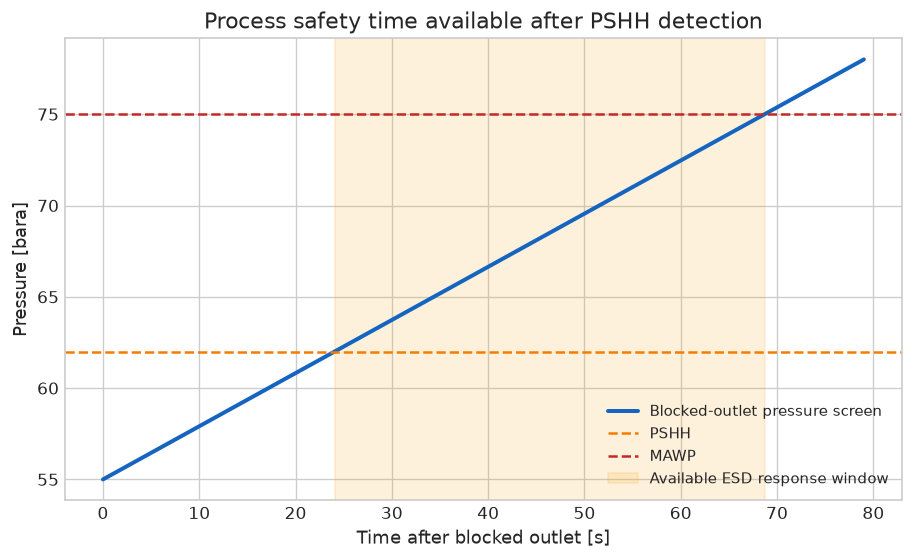

In [4]:
time_axis_s = np.linspace(0.0, time_to_mawp_s * 1.15, 250)
pressure_axis_bara = (
    normal_pressure_bara
    + pressure_rate_bara_s * time_axis_s
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    time_axis_s,
    pressure_axis_bara,
    linewidth=2.4,
    color="#1565C0",
    label="Blocked-outlet pressure screen",
)
ax.axhline(
    trip_pressure_bara,
    linestyle="--",
    color="#F57C00",
    label="PSHH",
)
ax.axhline(
    mawp_bara,
    linestyle="--",
    color="#C62828",
    label="MAWP",
)
ax.axvspan(
    time_to_trip_s,
    time_to_mawp_s,
    alpha=0.16,
    color="#F9A825",
    label="Available ESD response window",
)
ax.set(
    xlabel="Time after blocked outlet [s]",
    ylabel="Pressure [bara]",
    title="Process safety time available after PSHH detection",
)
ax.legend()
plt.show()

## Cause-and-effect matrix

In [5]:
cause_effect = pd.DataFrame(
    [
        {
            "cause": "PAHH-101: 62 bara",
            "alarm": "PAHH",
            "close ESDV-101": "X",
            "trip K-101": "X",
            "open BDV-101": "Delay",
            "operator reset": "Permissive",
            "safe-state evidence": "Pressure remains below MAWP",
        },
        {
            "cause": "LAHH-101",
            "alarm": "LAHH",
            "close ESDV-101": "X",
            "trip K-101": "X",
            "open BDV-101": "-",
            "operator reset": "Permissive",
            "safe-state evidence": "No liquid carry-over",
        },
        {
            "cause": "FGS confirmed gas",
            "alarm": "GAHH",
            "close ESDV-101": "X",
            "trip K-101": "X",
            "open BDV-101": "Area logic",
            "operator reset": "Manual",
            "safe-state evidence": "Isolate and reduce inventory",
        },
        {
            "cause": "Manual ESD",
            "alarm": "ESD",
            "close ESDV-101": "X",
            "trip K-101": "X",
            "open BDV-101": "Delay",
            "operator reset": "Manual",
            "safe-state evidence": "Verified sequence completion",
        },
    ]
)
display(cause_effect)

,cause,alarm,close ESDV-101,trip K-101,open BDV-101,operator reset,safe-state evidence
0,PAHH-101: 62 bara,PAHH,X,X,Delay,Permissive,Pressure remains below MAWP
1,LAHH-101,LAHH,X,X,-,Permissive,No liquid carry-over
2,FGS confirmed gas,GAHH,X,X,Area logic,Manual,Isolate and reduce inventory
3,Manual ESD,ESD,X,X,Delay,Manual,Verified sequence completion


## Native ESD response-time budgets

The native simulator adds sensor detection, logic-solver processing, solenoid
delay, and valve stroke. Three cases are compared:

- `As designed`: nominal response allocation;
- `Degraded`: slower sensing and final element;
- `Unacceptable`: delayed detection and a slow valve.

In [6]:
EsdResponseTimeSimulator = jpype.JClass(
    "neqsim.process.safety.esd.EsdResponseTimeSimulator"
)

response_cases = [
    {
        "case": "As designed",
        "detection_s": 0.8,
        "logic_s": 0.2,
        "solenoid_s": 0.4,
        "valve_stroke_s": 10.0,
    },
    {
        "case": "Degraded",
        "detection_s": 2.0,
        "logic_s": 0.8,
        "solenoid_s": 0.8,
        "valve_stroke_s": 23.0,
    },
    {
        "case": "Unacceptable",
        "detection_s": 3.0,
        "logic_s": 1.0,
        "solenoid_s": 1.0,
        "valve_stroke_s": 55.0,
    },
]

response_results = {}
response_rows = []
for case_values in response_cases:
    simulator = (
        EsdResponseTimeSimulator()
        .setSifTag("SIF-PAHH-101")
        .setAllowableResponseTimeS(available_response_time_s)
        .addDetection(
            "PT-101 2oo3 detection",
            case_values["detection_s"],
        )
        .addLogic(
            "SIS scan, vote, and output",
            case_values["logic_s"],
        )
        .addValve(
            "ESDV-101",
            case_values["solenoid_s"],
            case_values["valve_stroke_s"],
        )
    )
    result = simulator.evaluate()
    response_results[case_values["case"]] = result
    response_rows.append(
        {
            "case": case_values["case"],
            "detection [s]": result.getDetectionTimeS(),
            "logic [s]": result.getLogicTimeS(),
            "final element [s]": result.getFinalElementTimeS(),
            "total [s]": result.getTotalResponseTimeS(),
            "allowable [s]": result.getAllowableResponseTimeS(),
            "margin [s]": result.getMarginS(),
            "accepted": bool(result.isWithinBudget()),
        }
    )
    print(result.summary())

response_df = pd.DataFrame(response_rows).round(2)
display(response_df)

ESD response time (NOG 070 / IEC 61511) - SIF-PAHH-101:
  Detection      : 0.80 s
  Logic solver   : 0.20 s
  Final element  : 10.40 s
  TOTAL          : 11.40 s
  Allowable      : 44.66 s (margin 33.26 s) -> OK

ESD response time (NOG 070 / IEC 61511) - SIF-PAHH-101:
  Detection      : 2.00 s
  Logic solver   : 0.80 s
  Final element  : 23.80 s
  TOTAL          : 26.60 s
  Allowable      : 44.66 s (margin 18.06 s) -> OK

ESD response time (NOG 070 / IEC 61511) - SIF-PAHH-101:
  Detection      : 3.00 s
  Logic solver   : 1.00 s
  Final element  : 56.00 s
  TOTAL          : 60.00 s
  Allowable      : 44.66 s (margin -15.34 s) -> EXCEEDED



,case,detection [s],logic [s],final element [s],total [s],allowable [s],margin [s],accepted
0,As designed,0.8,0.2,10.4,11.4,44.66,33.26,True
1,Degraded,2.0,0.8,23.8,26.6,44.66,18.06,True
2,Unacceptable,3.0,1.0,56.0,60.0,44.66,-15.34,False


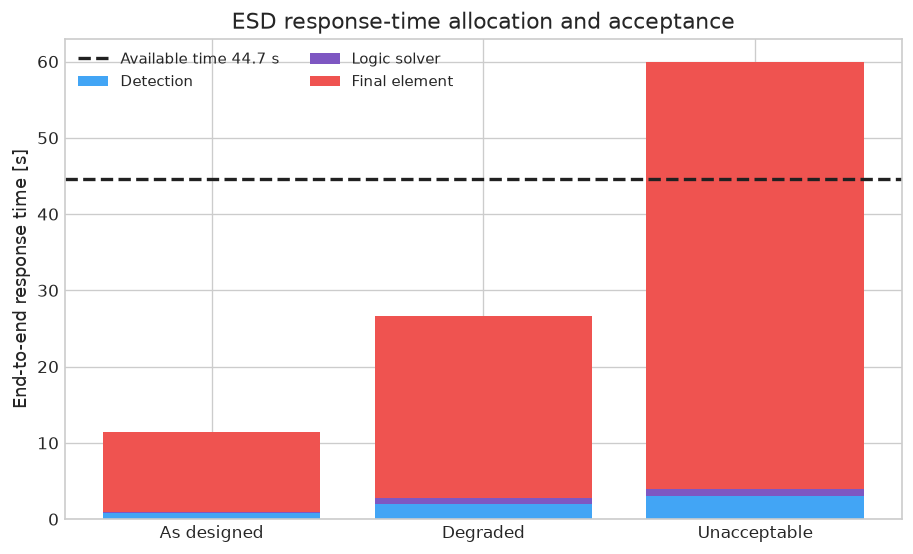

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.2))
bottom = np.zeros(len(response_df))
colors = ["#42A5F5", "#7E57C2", "#EF5350"]
for column, label, color in zip(
    ["detection [s]", "logic [s]", "final element [s]"],
    ["Detection", "Logic solver", "Final element"],
    colors,
):
    values = response_df[column].to_numpy()
    ax.bar(
        response_df["case"],
        values,
        bottom=bottom,
        label=label,
        color=color,
    )
    bottom += values

ax.axhline(
    available_response_time_s,
    color="#212121",
    linestyle="--",
    linewidth=2,
    label=f"Available time {available_response_time_s:.1f} s",
)
ax.set(
    ylabel="End-to-end response time [s]",
    title="ESD response-time allocation and acceptance",
)
ax.legend(ncol=2)
plt.show()

## Detection and valve-stroke sensitivity

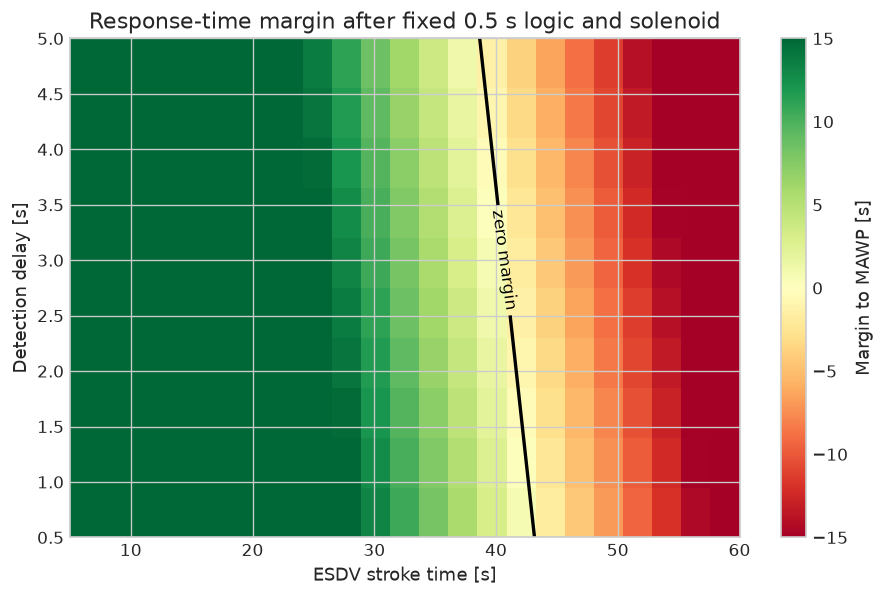

In [8]:
detection_grid_s = np.linspace(0.5, 5.0, 10)
valve_grid_s = np.linspace(5.0, 60.0, 23)
response_margin_grid = np.zeros(
    (len(detection_grid_s), len(valve_grid_s))
)

fixed_logic_s = 0.5
fixed_solenoid_s = 0.5
for row_index, detection_s in enumerate(detection_grid_s):
    for column_index, valve_s in enumerate(valve_grid_s):
        total_s = (
            detection_s
            + fixed_logic_s
            + fixed_solenoid_s
            + valve_s
        )
        response_margin_grid[row_index, column_index] = (
            available_response_time_s - total_s
        )

fig, ax = plt.subplots(figsize=(9, 5.4))
image = ax.imshow(
    response_margin_grid,
    origin="lower",
    aspect="auto",
    extent=[
        valve_grid_s.min(),
        valve_grid_s.max(),
        detection_grid_s.min(),
        detection_grid_s.max(),
    ],
    cmap="RdYlGn",
    vmin=-15,
    vmax=15,
)
contour = ax.contour(
    valve_grid_s,
    detection_grid_s,
    response_margin_grid,
    levels=[0.0],
    colors="black",
    linewidths=2,
)
ax.clabel(contour, fmt={0.0: "zero margin"})
ax.set(
    xlabel="ESDV stroke time [s]",
    ylabel="Detection delay [s]",
    title="Response-time margin after fixed 0.5 s logic and solenoid",
)
fig.colorbar(image, ax=ax, label="Margin to MAWP [s]")
plt.show()

## Evidence-linked barrier register

A barrier is not credited merely because its name appears in a HAZOP row. The
example links:

- document evidence;
- a performance standard;
- a barrier status and PFD claim;
- equipment and hazard identifiers;
- a safety-critical element (SCE).

The documents below are synthetic placeholders that show the required traceability
structure.

In [9]:
DocumentEvidence = jpype.JClass(
    "neqsim.process.safety.barrier.DocumentEvidence"
)
PerformanceStandard = jpype.JClass(
    "neqsim.process.safety.barrier.PerformanceStandard"
)
DemandMode = jpype.JClass(
    "neqsim.process.safety.barrier.PerformanceStandard$DemandMode"
)
SafetyBarrier = jpype.JClass(
    "neqsim.process.safety.barrier.SafetyBarrier"
)
BarrierType = jpype.JClass(
    "neqsim.process.safety.barrier.SafetyBarrier$BarrierType"
)
BarrierStatus = jpype.JClass(
    "neqsim.process.safety.barrier.SafetyBarrier$BarrierStatus"
)
SafetyCriticalElement = jpype.JClass(
    "neqsim.process.safety.barrier.SafetyCriticalElement"
)
ElementType = jpype.JClass(
    "neqsim.process.safety.barrier.SafetyCriticalElement$ElementType"
)
BarrierRegister = jpype.JClass(
    "neqsim.process.safety.barrier.BarrierRegister"
)

srs_evidence = DocumentEvidence(
    "EV-SRS-101",
    "SRS-HP-SEP-001",
    "HP separator overpressure SRS",
    "A",
    "Section 4.2",
    12,
    "SIF-PAHH-101",
    "Close ESDV-101 before V-101 pressure reaches MAWP.",
    0.95,
)
cause_effect_evidence = DocumentEvidence(
    "EV-CE-101",
    "CE-HP-SEP-001",
    "HP separator cause and effect",
    "A",
    "Row PAHH-101",
    3,
    "PAHH-101",
    "PAHH-101 closes ESDV-101 and trips K-101.",
    0.95,
)
test_evidence = DocumentEvidence(
    "EV-FAT-101",
    "FAT-SIF-PAHH-101",
    "Synthetic SIF functional test",
    "0",
    "Test 7",
    18,
    "Response-time result",
    (
        f"End-to-end response {response_df.loc[0, 'total [s]']:.1f} s "
        f"against {available_response_time_s:.1f} s available."
    ),
    0.90,
)

performance_standard = (
    PerformanceStandard("PS-SIF-PAHH-101")
    .setTitle("HP separator high-pressure isolation")
    .setSafetyFunction(
        "Detect high pressure and isolate continuing inflow"
    )
    .setDemandMode(DemandMode.LOW_DEMAND)
    .setTargetPfd(1.0e-3)
    .setRequiredAvailability(0.99)
    .setProofTestIntervalHours(8760.0)
    .setResponseTimeSeconds(available_response_time_s)
    .addAcceptanceCriterion(
        "Close ESDV-101 before V-101 pressure reaches MAWP"
    )
    .addAcceptanceCriterion(
        "Trip export compressor K-101 on PAHH-101"
    )
    .addEvidence(srs_evidence)
    .addEvidence(cause_effect_evidence)
    .addEvidence(test_evidence)
)

psv_performance_standard = (
    PerformanceStandard("PS-PSV-101")
    .setTitle("HP separator pressure-relief performance")
    .setSafetyFunction(
        "Relieve the blocked-outlet load without exceeding MAWP"
    )
    .setDemandMode(DemandMode.LOW_DEMAND)
    .setTargetPfd(1.0e-2)
    .setRequiredAvailability(0.99)
    .setProofTestIntervalHours(8760.0)
    .addAcceptanceCriterion(
        "PSV-101 capacity exceeds the governing relief load"
    )
    .addEvidence(cause_effect_evidence)
)

operator_performance_standard = (
    PerformanceStandard("PS-OPERATOR-PAH-101")
    .setTitle("Operator response to separator high pressure")
    .setSafetyFunction(
        "Diagnose PAH-101 and manually isolate before PAHH"
    )
    .setDemandMode(DemandMode.LOW_DEMAND)
    .setTargetPfd(0.10)
    .setResponseTimeSeconds(time_to_trip_s)
    .addAcceptanceCriterion(
        "Operator action is completed before the PAHH set point"
    )
    .addEvidence(cause_effect_evidence)
)

pressure_trip = (
    SafetyBarrier("B-SIF-PAHH-101")
    .setName("PAHH inlet isolation SIF")
    .setDescription("2oo3 pressure detection, SIS, and ESDV-101")
    .setType(BarrierType.PREVENTION)
    .setStatus(BarrierStatus.AVAILABLE)
    .setSafetyFunction("Stop continuing inflow before MAWP")
    .setOwner("Automation")
    .setPfd(1.0e-3)
    .setEffectiveness(0.99)
    .setPerformanceStandard(performance_standard)
    .addEquipmentTag("PT-101A/B/C")
    .addEquipmentTag("ESDV-101")
    .addHazardId("HAZ-OVERPRESSURE-001")
    .addEvidence(srs_evidence)
    .addEvidence(test_evidence)
)

pressure_relief = (
    SafetyBarrier("B-PSV-101")
    .setName("HP separator pressure relief")
    .setDescription("PSV-101 to flare")
    .setType(BarrierType.MITIGATION)
    .setStatus(BarrierStatus.AVAILABLE)
    .setSafetyFunction("Limit separator pressure if isolation fails")
    .setOwner("Technical safety")
    .setPfd(1.0e-2)
    .setEffectiveness(0.98)
    .setPerformanceStandard(psv_performance_standard)
    .addEquipmentTag("PSV-101")
    .addEquipmentTag("V-101")
    .addHazardId("HAZ-OVERPRESSURE-001")
    .addEvidence(cause_effect_evidence)
)

operator_response = (
    SafetyBarrier("B-OPERATOR-101")
    .setName("Operator response to PAH")
    .setDescription("Control-room diagnosis and manual isolation")
    .setType(BarrierType.PREVENTION)
    .setStatus(BarrierStatus.AVAILABLE)
    .setSafetyFunction("Provide non-SIS recovery before PAHH")
    .setOwner("Operations")
    .setPfd(0.10)
    .setEffectiveness(0.90)
    .setPerformanceStandard(operator_performance_standard)
    .addEquipmentTag("PAH-101")
    .addHazardId("HAZ-OVERPRESSURE-001")
    .addEvidence(cause_effect_evidence)
)

pressure_sce = (
    SafetyCriticalElement("SCE-V-101-PROTECTION")
    .setTag("V-101")
    .setName("HP separator pressure protection")
    .setType(ElementType.PROCESS_EQUIPMENT)
    .setOwner("Technical safety")
    .addEquipmentTag("V-101")
    .addEquipmentTag("ESDV-101")
    .addEquipmentTag("PSV-101")
    .addBarrier(pressure_trip)
    .addBarrier(pressure_relief)
    .addBarrier(operator_response)
    .addEvidence(srs_evidence)
    .addEvidence(cause_effect_evidence)
)

barrier_register = (
    BarrierRegister("BR-HP-SEP-001")
    .setName("HP separator overpressure barrier register")
    .addEvidence(srs_evidence)
    .addEvidence(cause_effect_evidence)
    .addEvidence(test_evidence)
    .addPerformanceStandard(performance_standard)
    .addPerformanceStandard(psv_performance_standard)
    .addPerformanceStandard(operator_performance_standard)
    .addSafetyCriticalElement(pressure_sce)
)

register_json = json.loads(str(barrier_register.toJson()))
print(json.dumps(register_json, indent=2))

{
  "registerId": "BR-HP-SEP-001",
  "name": "HP separator overpressure barrier register",
  "safetyCriticalElements": [
    {
      "id": "SCE-V-101-PROTECTION",
      "tag": "V-101",
      "name": "HP separator pressure protection",
      "type": "PROCESS_EQUIPMENT",
      "owner": "Technical safety",
      "equipmentTags": [
        "V-101",
        "ESDV-101",
        "PSV-101"
      ],
      "availableBarrierCount": 3,
      "hasImpairedBarrier": false,
      "barriers": [
        {
          "id": "B-SIF-PAHH-101",
          "name": "PAHH inlet isolation SIF",
          "description": "2oo3 pressure detection, SIS, and ESDV-101",
          "type": "PREVENTION",
          "status": "AVAILABLE",
          "safetyFunction": "Stop continuing inflow before MAWP",
          "owner": "Automation",
          "pfd": 0.001,
          "effectiveness": 0.99,
          "riskReductionFactor": 1000.0,
          "linkedEquipmentTags": [
            "PT-101A/B/C",
            "ESDV-101"
         

In [10]:
barrier_rows = []
for barrier in barrier_register.getBarriers():
    barrier_rows.append(
        {
            "barrier id": str(barrier.getId()),
            "name": str(barrier.getName()),
            "type": str(barrier.getType()),
            "status": str(barrier.getStatus()),
            "PFD": float(barrier.getPfd()),
            "RRF": float(barrier.getRiskReductionFactor()),
            "owner": str(barrier.getOwner()),
            "traceable evidence": bool(
                barrier.hasTraceableEvidence()
            ),
            "validation findings": len(barrier.validate()),
        }
    )
barrier_df = pd.DataFrame(barrier_rows)
display(barrier_df)
print("Register findings:", list(barrier_register.validate()))

Register findings: []


,barrier id,name,type,status,PFD,RRF,owner,traceable evidence,validation findings
0,B-SIF-PAHH-101,PAHH inlet isolation SIF,PREVENTION,AVAILABLE,0.001,1000.0,Automation,True,0
1,B-PSV-101,HP separator pressure relief,MITIGATION,AVAILABLE,0.010,100.0,Technical safety,True,0
2,B-OPERATOR-101,Operator response to PAH,PREVENTION,AVAILABLE,0.100,10.0,Operations,True,0


## Barrier impairment scenarios

The following frequency multiplication is an illustrative low-demand screening:

$$
f_{\mathrm{residual}} =
f_{\mathrm{initiating}}
\prod_i \mathrm{PFD}_i
$$

It is valid only when credited layers are independent, effective for the scenario,
auditable, and allowed by the approved LOPA method. The operator layer is not
combined with the PAHH SIF here because alarm/SIF independence requires explicit
verification.

In [11]:
initiating_frequency_per_year = 0.10
impairment_scenarios = [
    {
        "scenario": "All credited barriers available",
        "SIF PFD": 1.0e-3,
        "PSV PFD": 1.0e-2,
        "credited layers": "SIF × PSV",
    },
    {
        "scenario": "SIF bypassed",
        "SIF PFD": 1.0,
        "PSV PFD": 1.0e-2,
        "credited layers": "PSV only",
    },
    {
        "scenario": "PSV unavailable",
        "SIF PFD": 1.0e-3,
        "PSV PFD": 1.0,
        "credited layers": "SIF only",
    },
    {
        "scenario": "SIF bypassed and PSV unavailable",
        "SIF PFD": 1.0,
        "PSV PFD": 1.0,
        "credited layers": "None",
    },
]
impairment_df = pd.DataFrame(impairment_scenarios)
impairment_df["residual frequency [1/yr]"] = (
    initiating_frequency_per_year
    * impairment_df["SIF PFD"]
    * impairment_df["PSV PFD"]
)
impairment_df["risk increase vs normal"] = (
    impairment_df["residual frequency [1/yr]"]
    / impairment_df.loc[0, "residual frequency [1/yr]"]
)
display(impairment_df)

,scenario,SIF PFD,PSV PFD,credited layers,residual frequency [1/yr],risk increase vs normal
0,All credited barriers available,0.001,0.01,SIF × PSV,0.000001,1.0
1,SIF bypassed,1.000,0.01,PSV only,0.001000,1000.0
2,PSV unavailable,0.001,1.00,SIF only,0.000100,100.0
3,SIF bypassed and PSV unavailable,1.000,1.00,None,0.100000,100000.0


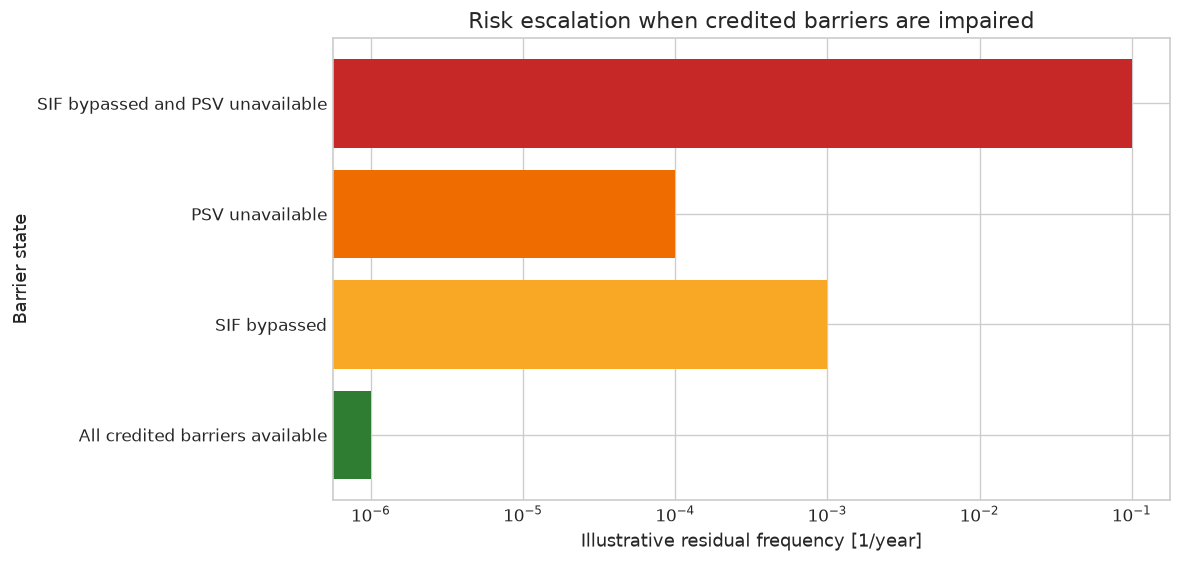

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    impairment_df["scenario"],
    impairment_df["residual frequency [1/yr]"],
    color=["#2E7D32", "#F9A825", "#EF6C00", "#C62828"],
)
ax.set(
    xlabel="Illustrative residual frequency [1/year]",
    ylabel="Barrier state",
    title="Risk escalation when credited barriers are impaired",
    xscale="log",
)
plt.show()

## Acceptance record

In [13]:
as_designed = response_results["As designed"]
acceptance_record = pd.DataFrame(
    [
        {
            "requirement": "End-to-end response within process safety time",
            "evidence": (
                f"{as_designed.getTotalResponseTimeS():.2f} s "
                f"≤ {available_response_time_s:.2f} s"
            ),
            "status": (
                "PASS"
                if as_designed.isWithinBudget()
                else "FAIL"
            ),
        },
        {
            "requirement": "Performance standard has traceable evidence",
            "evidence": (
                f"{len(performance_standard.getEvidence())} evidence records"
            ),
            "status": (
                "PASS"
                if performance_standard.hasTraceableEvidence()
                else "FAIL"
            ),
        },
        {
            "requirement": "Barrier register validation has no findings",
            "evidence": (
                f"{len(barrier_register.validate())} findings"
            ),
            "status": (
                "PASS"
                if len(barrier_register.validate()) == 0
                else "FAIL"
            ),
        },
        {
            "requirement": "Cause-and-effect covers PAHH isolation",
            "evidence": (
                cause_effect.loc[0, "close ESDV-101"]
            ),
            "status": (
                "PASS"
                if cause_effect.loc[0, "close ESDV-101"] == "X"
                else "FAIL"
            ),
        },
        {
            "requirement": "Degraded and unacceptable cases are detected",
            "evidence": (
                response_df.set_index("case")["accepted"].to_dict()
            ),
            "status": (
                "PASS"
                if (
                    response_df.loc[
                        response_df["case"] == "Unacceptable",
                        "accepted",
                    ].iloc[0]
                    == False
                )
                else "FAIL"
            ),
        },
    ]
)
display(acceptance_record)

,requirement,evidence,status
0,End-to-end response within process safety time,11.40 s ≤ 44.66 s,PASS
1,Performance standard has traceable evidence,3 evidence records,PASS
2,Barrier register validation has no findings,0 findings,PASS
3,Cause-and-effect covers PAHH isolation,X,PASS
4,Degraded and unacceptable cases are detected,"{'As designed': True, 'Degraded': True, 'Unacceptable': False}",PASS


## Validation and quality gates

In [14]:
validation = pd.DataFrame(
    [
        {
            "check": "Pinned NeqSim release",
            "value": runtime["neqsim"],
            "pass": runtime["neqsim"] == "3.16.0",
        },
        {
            "check": "Composition closes",
            "value": sum(value for _, value in barrier_components),
            "pass": (
                abs(
                    sum(value for _, value in barrier_components)
                    - 1.0
                )
                < 1.0e-12
            ),
        },
        {
            "check": "PSHH occurs before MAWP",
            "value": time_to_trip_s < time_to_mawp_s,
            "pass": time_to_trip_s < time_to_mawp_s,
        },
        {
            "check": "As-designed ESD response is accepted",
            "value": bool(as_designed.isWithinBudget()),
            "pass": bool(as_designed.isWithinBudget()),
        },
        {
            "check": "Unacceptable response is rejected",
            "value": bool(
                response_results["Unacceptable"].isWithinBudget()
            ),
            "pass": not bool(
                response_results["Unacceptable"].isWithinBudget()
            ),
        },
        {
            "check": "Barrier register validates",
            "value": len(barrier_register.validate()),
            "pass": len(barrier_register.validate()) == 0,
        },
        {
            "check": "Every acceptance requirement passes",
            "value": acceptance_record["status"].tolist(),
            "pass": bool(
                (acceptance_record["status"] == "PASS").all()
            ),
        },
    ]
)
display(validation)
assert validation["pass"].all()
print("All barrier-performance validation checks passed.")

All barrier-performance validation checks passed.


,check,value,pass
0,Pinned NeqSim release,3.16.0,True
1,Composition closes,1.0,True
2,PSHH occurs before MAWP,True,True
3,As-designed ESD response is accepted,True,True
4,Unacceptable response is rejected,False,True
5,Barrier register validates,0,True
6,Every acceptance requirement passes,"[PASS, PASS, PASS, PASS, PASS]",True


## Interpretation and limitations

- The as-designed 11.4 s response fits within the calculated process safety time;
  the slow-valve case does not.
- The response budget depends directly on continuing inflow, gas-space volume,
  initial pressure, trip set point, temperature, and real-gas properties.
- The pressure-rise relation is an early screen. A final study needs dynamic
  equipment, controllers, valve characteristics, relief, heat transfer, and
  uncertainty.
- PFD values and evidence records are illustrative. They are not certified
  reliability data.
- Multiplication of PFDs requires demonstrated independence and scenario
  applicability.
- A valid register is necessary for traceability but is not proof that the
  hardware, software, or operating organization meets the requirement.

## Summary and suggested exercises

The notebook completes this governed handoff:

`HAZOP scenario → process safety time → C&E → response test → performance standard → barrier register`

Suggested exercises:

1. replace the pressure screen with a dynamic vessel-filling calculation;
2. use field stroke-test data and compare model-to-field response;
3. add partial-stroke and proof-test coverage;
4. evaluate common-cause failure for 2oo3 transmitters;
5. export the barrier register and acceptance record to a review package.

## References

- [IEC 61511-1:2016 — SIS lifecycle requirements](https://webstore.iec.ch/en/publication/24241)
- [IEC 61511 series](https://webstore.iec.ch/en/publication/5527)
- [ISO 17776:2016 — major accident hazard management](https://www.iso.org/standard/63062.html)
- [NeqSim ESD testing workflow](https://equinor.github.io/neqsim/safety/esd_testing_workflow)
- [NeqSim barrier management](https://equinor.github.io/neqsim/safety/barrier_management)